<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/salsabil/canteen_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/refs/heads/main/data/canteen_dataset.csv"
df = pd.read_csv(url)
df.head()

,Date,Meal,Canteen_Section,Food_Category,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss
0,2025-07-30,Dinner,B,Vegetables,1.50,3.0,4.50
1,2025-06-15,Breakfast,B,Rice,3.69,2.0,7.38
2,2025-07-29,Breakfast,A,Soup,1.54,1.5,2.31
3,2025-07-17,Breakfast,A,Soup,1.81,1.5,2.71
4,2025-07-03,Dinner,D,Rice,4.69,2.0,9.38


##Understanding the dataset first

In [3]:
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2600 non-null   object 
 1   Meal               2600 non-null   object 
 2   Canteen_Section    2600 non-null   object 
 3   Food_Category      2600 non-null   object 
 4   Waste_Weight_kg    2600 non-null   float64
 5   Unit_Price_per_kg  2600 non-null   float64
 6   Cost_Loss          2600 non-null   float64
dtypes: float64(3), object(4)
memory usage: 142.3+ KB


,0
Date,0
Meal,0
Canteen_Section,0
Food_Category,0
Waste_Weight_kg,0
Unit_Price_per_kg,0
Cost_Loss,0


In [4]:
for col in ["Meal", "Canteen_Section", "Food_Category"]:
    print("\n", col)
    print(df[col].value_counts())


 Meal
Meal
Breakfast    869
Lunch        867
Dinner       864
Name: count, dtype: int64

 Canteen_Section
Canteen_Section
B    654
A    652
D    648
C    646
Name: count, dtype: int64

 Food_Category
Food_Category
Rice          659
Meat          653
Vegetables    651
Soup          637
Name: count, dtype: int64


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.day_name()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               2600 non-null   datetime64[ns]
 1   Meal               2600 non-null   object        
 2   Canteen_Section    2600 non-null   object        
 3   Food_Category      2600 non-null   object        
 4   Waste_Weight_kg    2600 non-null   float64       
 5   Unit_Price_per_kg  2600 non-null   float64       
 6   Cost_Loss          2600 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 142.3+ KB


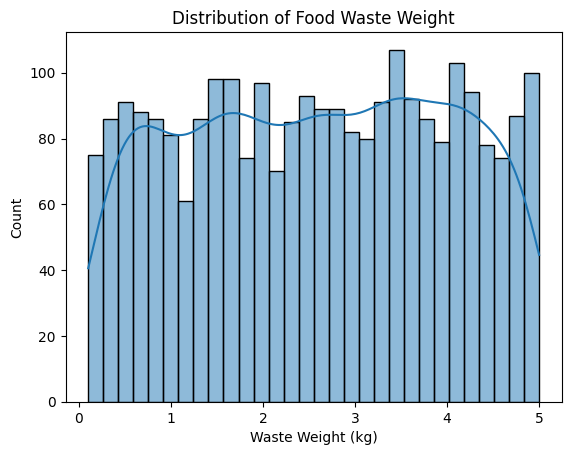

In [6]:
sns.histplot(
    df["Waste_Weight_kg"],
    bins=30,
    kde=True
)
plt.title("Distribution of Food Waste Weight")
plt.xlabel("Waste Weight (kg)")
plt.show()

##Research question:
Does meal period influence waste generation?

In [7]:
meal_waste = (
    df.groupby("Meal")["Waste_Weight_kg"]
    .mean()
    .sort_values(ascending=False)
)
meal_waste

,Waste_Weight_kg
Meal,
Dinner,2.649965
Lunch,2.631845
Breakfast,2.476628


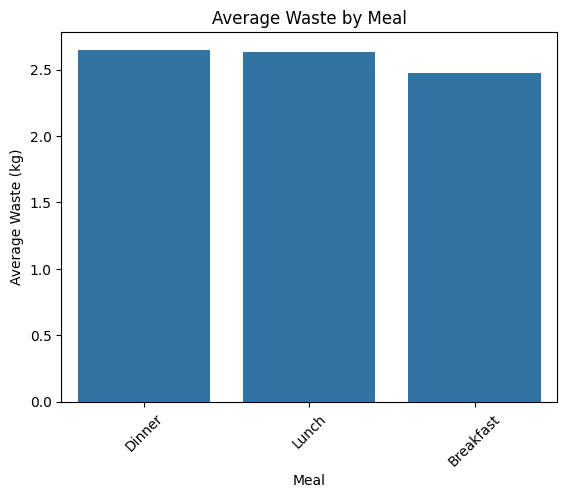

In [8]:
sns.barplot(
    x=meal_waste.index,
    y=meal_waste.values
)

plt.title("Average Waste by Meal")
plt.ylabel("Average Waste (kg)")
plt.xticks(rotation=45)
plt.show()

From the above graph, we can say that dinner generated the highest average waste, indicating meal scheduling or preparation quantity may affect waste.

##Research question:

Which food categories contribute most to waste?

In [9]:
category_waste = (
    df.groupby("Food_Category")["Waste_Weight_kg"]
    .mean()
    .sort_values(ascending=False)
)
category_waste

,Waste_Weight_kg
Food_Category,
Soup,2.662826
Rice,2.609954
Vegetables,2.592074
Meat,2.480781


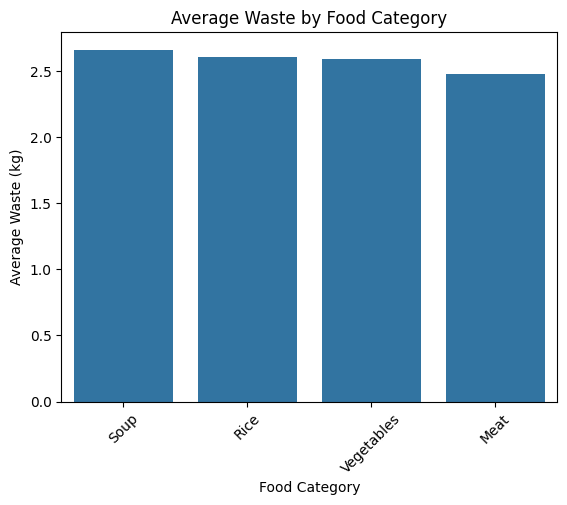

In [10]:
sns.barplot(
    x=category_waste.index,
    y=category_waste.values
)

plt.title("Average Waste by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Average Waste (kg)")
plt.xticks(rotation=45)

plt.show()

##Research question:

Are certain sections responsible for higher waste?

In [11]:
section_waste = (
    df.groupby("Canteen_Section")["Waste_Weight_kg"]
    .mean()
    .sort_values(ascending=False)
)
section_waste

,Waste_Weight_kg
Canteen_Section,
C,2.644040
B,2.614144
D,2.572454
A,2.513681


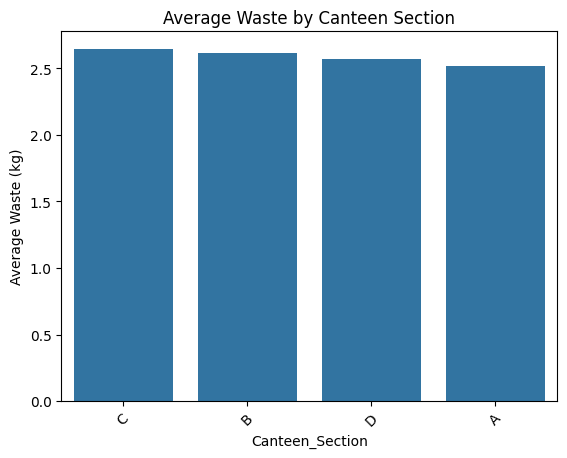

In [12]:
sns.barplot(
    x=section_waste.index,
    y=section_waste.values
)

plt.title("Average Waste by Canteen Section")
plt.ylabel("Average Waste (kg)")
plt.xticks(rotation=45)
plt.show()

Determinig relationship between waste and finantial loss

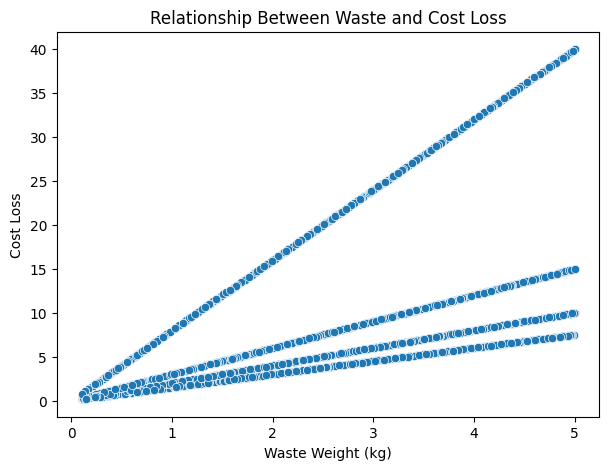

In [13]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Waste_Weight_kg",
    y="Cost_Loss"
)

plt.title("Relationship Between Waste and Cost Loss")
plt.xlabel("Waste Weight (kg)")
plt.ylabel("Cost Loss")

plt.show()

###Analysing if price affect waste and does waste strongly determine cost loss or not

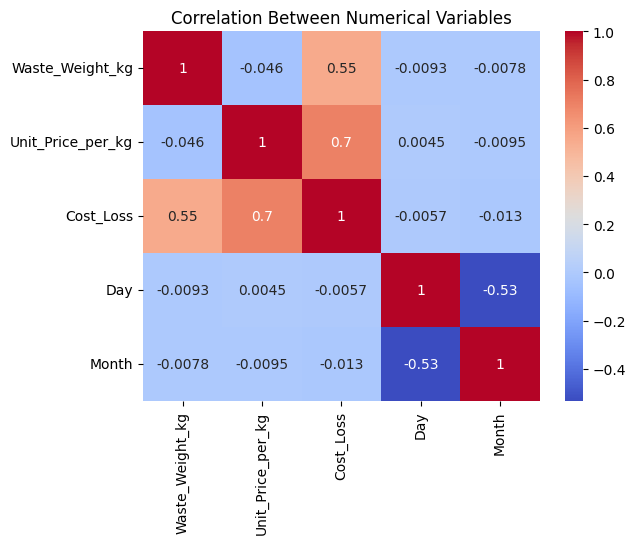

In [14]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

##Checking outliers

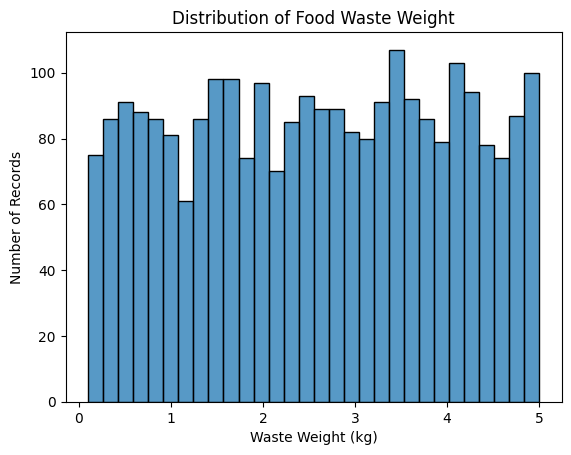

In [15]:
sns.histplot(
    data=df,
    x="Waste_Weight_kg",
    bins=30
)

plt.title("Distribution of Food Waste Weight")
plt.xlabel("Waste Weight (kg)")
plt.ylabel("Number of Records")

plt.show()

##Analysing total waste contribution



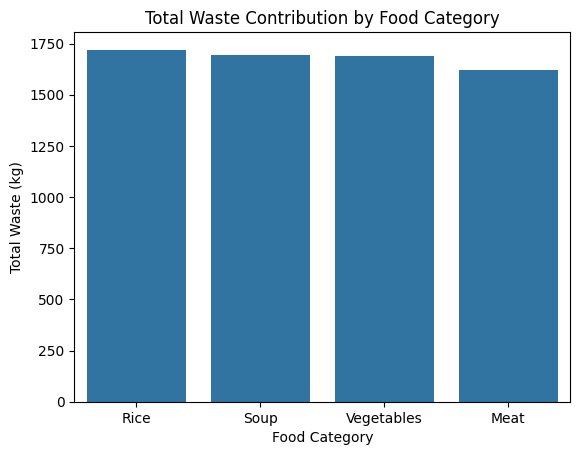

In [16]:
total_category_waste = (
    df.groupby("Food_Category")["Waste_Weight_kg"]
    .sum()
    .sort_values(ascending=False)
)
total_category_waste

sns.barplot(
    x=total_category_waste.index,
    y=total_category_waste.values
)

plt.title("Total Waste Contribution by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Total Waste (kg)")

plt.show()

We can interpret from here that, Although some food categories may not have the highest average waste per record, they may contribute the largest overall waste because they appear more frequently.

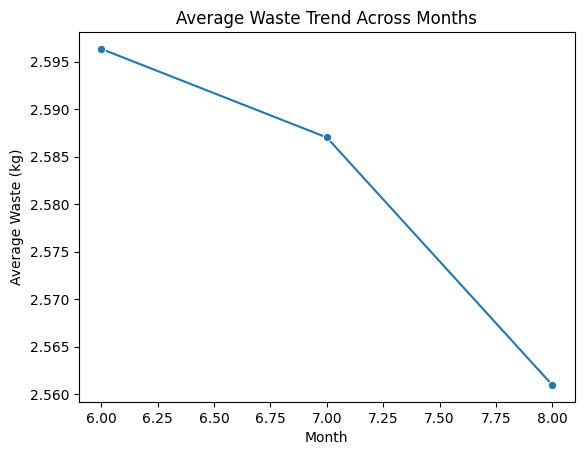

In [17]:
monthly_waste = (
    df.groupby("Month")["Waste_Weight_kg"]
    .mean()
)
monthly_waste

sns.lineplot(
    x=monthly_waste.index,
    y=monthly_waste.values,
    marker="o"
)

plt.title("Average Waste Trend Across Months")
plt.xlabel("Month")
plt.ylabel("Average Waste (kg)")

plt.show()

Waste generation changes over time, suggesting possible seasonal or operational effects.

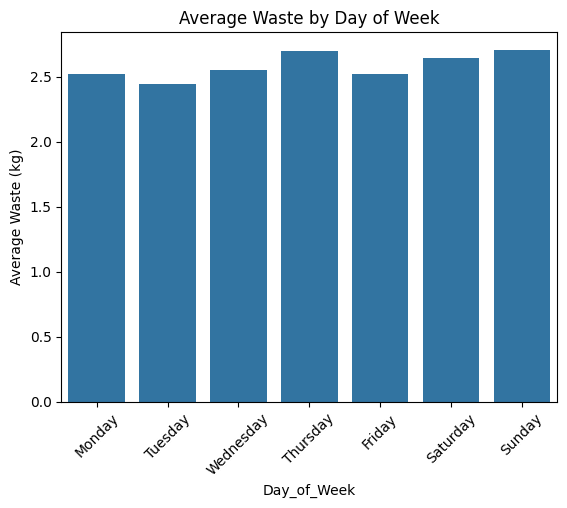

In [18]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_waste = (
    df.groupby("Day_of_Week")["Waste_Weight_kg"]
    .mean()
    .reindex(weekday_order)
)

weekday_waste

sns.barplot(
    x=weekday_waste.index,
    y=weekday_waste.values
)

plt.xticks(rotation=45)

plt.title("Average Waste by Day of Week")
plt.ylabel("Average Waste (kg)")

plt.show()

##Check for Duplicate Rows

In [20]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


##Check Categorical Values

In [21]:
categorical_cols = [
    "Meal",
    "Food_Category",
    "Canteen_Section"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Meal
['Dinner' 'Breakfast' 'Lunch']

Food_Category
['Vegetables' 'Rice' 'Soup' 'Meat']

Canteen_Section
['B' 'A' 'D' 'C']


##Clean Categorical Values

In [22]:
for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

##Verifying cleaned catergorical values

In [23]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Meal
['Dinner' 'Breakfast' 'Lunch']

Food_Category
['Vegetables' 'Rice' 'Soup' 'Meat']

Canteen_Section
['B' 'A' 'D' 'C']


##Check for Invalid Numerical Values

In [24]:
df.describe()

,Date,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month
count,2600,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,2025-07-10 17:30:05.538461440,2.585988,3.634808,9.233154,15.831154,6.824615
min,2025-06-11 00:00:00,0.100000,1.500000,0.150000,1.000000,6.000000
25%,2025-06-25 00:00:00,1.390000,2.000000,3.495000,8.000000,6.000000
50%,2025-07-11 00:00:00,2.600000,3.000000,6.360000,16.000000,7.000000
75%,2025-07-26 00:00:00,3.800000,8.000000,10.950000,23.000000,7.000000
max,2025-08-10 00:00:00,5.000000,8.000000,40.000000,31.000000,8.000000
std,NaN,1.408281,2.585178,8.952404,8.813420,0.681200


##Detect Outliers Using Boxplots

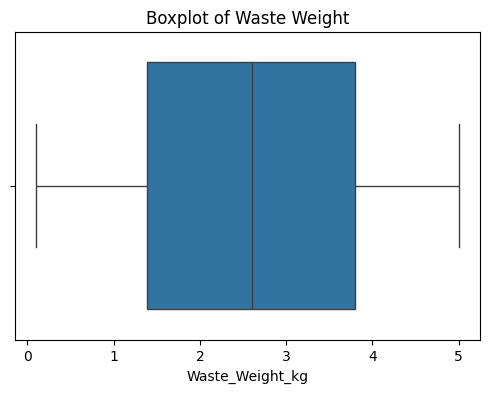

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Waste_Weight_kg"])

plt.title("Boxplot of Waste Weight")

plt.show()

###Detecting outliers in Cost Loss

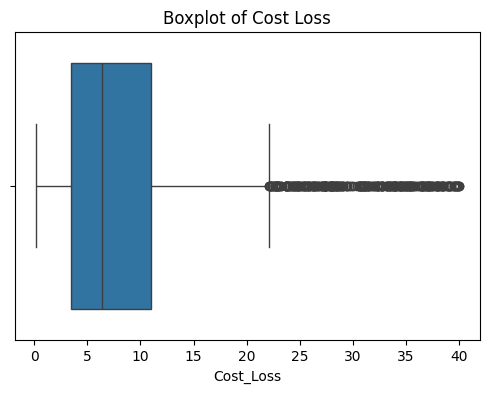

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Cost_Loss"])

plt.title("Boxplot of Cost Loss")

plt.show()

###Decide Whether to Remove Outliers

##Remove Unnecessary Columns

In [27]:
df = df.drop(columns=["Date"])

df.head()

,Meal,Canteen_Section,Food_Category,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Day_of_Week
0,Dinner,B,Vegetables,1.50,3.0,4.50,30,7,Wednesday
1,Breakfast,B,Rice,3.69,2.0,7.38,15,6,Sunday
2,Breakfast,A,Soup,1.54,1.5,2.31,29,7,Tuesday
3,Breakfast,A,Soup,1.81,1.5,2.71,17,7,Thursday
4,Dinner,D,Rice,4.69,2.0,9.38,3,7,Thursday


##Encode Categorical Variables

In [28]:
df = pd.get_dummies(
    df,
    columns=[
        "Meal",
        "Food_Category",
        "Canteen_Section",
        "Day_of_Week"
    ],
    drop_first=True
)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,Canteen_Section_B,Canteen_Section_C,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,1.50,3.0,4.50,30,7,True,False,False,False,True,True,False,False,False,False,False,False,False,True
1,3.69,2.0,7.38,15,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False
2,1.54,1.5,2.31,29,7,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,1.81,1.5,2.71,17,7,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,4.69,2.0,9.38,3,7,True,False,True,False,False,False,False,True,False,False,False,True,False,False


##Check Dataset after Encoding

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int32  
 4   Month                     2600 non-null   int32  
 5   Meal_Dinner               2600 non-null   bool   
 6   Meal_Lunch                2600 non-null   bool   
 7   Food_Category_Rice        2600 non-null   bool   
 8   Food_Category_Soup        2600 non-null   bool   
 9   Food_Category_Vegetables  2600 non-null   bool   
 10  Canteen_Section_B         2600 non-null   bool   
 11  Canteen_Section_C         2600 non-null   bool   
 12  Canteen_Section_D         2600 non-null   bool   
 13  Day_of_Week_Monday        2600 non-null   bool   
 14  Day_of_W

##Save the Cleaned Dataset

In [30]:
df.to_csv("canteen_dataset_cleaned.csv", index=False)